In [15]:
# Cellule 1 - Importer les bibliothèques
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import ttest_ind

In [16]:
# Cellule 2 - Charger les logs
log_path = Path("../logs/ab_predictions.jsonl")

df = pd.read_json(log_path, lines=True)
print(df.shape)
df.head()

(100, 6)


,user_id,variant,prediction,latency_ms,features,timestamp
0,user_0,A,1.130160,57.922363,"{'MedInc': 2.751913733030923, 'HouseAge': 11, ...",2026-05-12 12:13:55.003551+00:00
1,user_1,A,1.105840,51.220655,"{'MedInc': 3.449034416120581, 'HouseAge': 29, ...",2026-05-12 12:13:55.070923+00:00
2,user_2,A,3.057121,44.343948,"{'MedInc': 6.885761073731744, 'HouseAge': 14, ...",2026-05-12 12:13:55.157273+00:00
3,user_3,B,1.627880,46.051025,"{'MedInc': 4.760446754603583, 'HouseAge': 24, ...",2026-05-12 12:13:55.232884+00:00
4,user_4,B,3.784153,49.265862,"{'MedInc': 5.164124510536114, 'HouseAge': 49, ...",2026-05-12 12:13:55.296225+00:00


In [17]:
# Cellule 3 - Vérifier les colonnes

df.columns

Index(['user_id', 'variant', 'prediction', 'latency_ms', 'features',
       'timestamp'],
      dtype='str')

In [18]:
# Cellule 4 - Compter le nombre de requêtes par variante

df["variant"].value_counts()

variant
A    50
B    50
Name: count, dtype: int64

In [19]:
# Cellule 5 - Comparer les prédictions moyennes

df.groupby("variant")["prediction"].agg(["count", "mean", "std", "min", "max"])

,count,mean,std,min,max
variant,,,,,
A,50,2.439460,1.022269,0.71764,4.457415
B,50,2.656221,1.273455,0.66315,4.768758


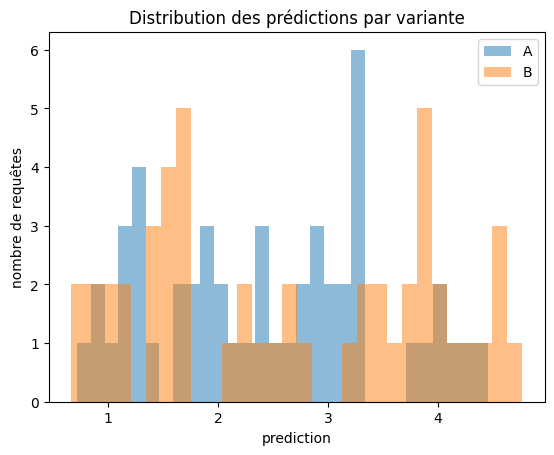

In [20]:
# Cellule 6 - Visualiser les distributions

for variant in ["A", "B"]:
    subset = df[df["variant"] == variant]
    plt.hist(subset["prediction"], alpha=0.5, bins=30, label=variant)

plt.legend()
plt.title("Distribution des prédictions par variante")
plt.xlabel("prediction")
plt.ylabel("nombre de requêtes")
plt.show()

In [21]:
# Cellule 7 - Comparer la latence

df.groupby("variant")["latency_ms"].agg(["count", "mean", "std", "max"])

,count,mean,std,max
variant,,,,
A,50,51.036906,9.541461,100.276947
B,50,49.047647,7.793676,73.716402


In [22]:
# Cellule 8 - Faire un T-test sur les prédictions

group_a = df[df["variant"] == "A"]["prediction"]
group_b = df[df["variant"] == "B"]["prediction"]

stat, pvalue = ttest_ind(group_a, group_b, equal_var=False)

print("statistique =", stat)
print("p-value =", pvalue)

statistique = -0.9385952430141321
p-value = 0.35035377182906663


In [23]:
# Cellule 9 : Ajouter une ground truth simulée

import numpy as np

# Simulation pédagogique d'une vérité terrain
# On suppose ici que la valeur réelle est proche de la prédiction,
# avec un bruit aléatoire ajouté.
df["actual_value"] = df["prediction"] + np.random.normal(
    loc=0,
    scale=0.3,
    size=len(df),
)

df.head()

,user_id,variant,prediction,latency_ms,features,timestamp,actual_value
0,user_0,A,1.130160,57.922363,"{'MedInc': 2.751913733030923, 'HouseAge': 11, ...",2026-05-12 12:13:55.003551+00:00,1.174048
1,user_1,A,1.105840,51.220655,"{'MedInc': 3.449034416120581, 'HouseAge': 29, ...",2026-05-12 12:13:55.070923+00:00,0.512433
2,user_2,A,3.057121,44.343948,"{'MedInc': 6.885761073731744, 'HouseAge': 14, ...",2026-05-12 12:13:55.157273+00:00,3.033704
3,user_3,B,1.627880,46.051025,"{'MedInc': 4.760446754603583, 'HouseAge': 24, ...",2026-05-12 12:13:55.232884+00:00,1.727729
4,user_4,B,3.784153,49.265862,"{'MedInc': 5.164124510536114, 'HouseAge': 49, ...",2026-05-12 12:13:55.296225+00:00,3.640966


In [24]:
# Cellule 10 : Calculer l’erreur absolue

df["absolute_error"] = (df["actual_value"] - df["prediction"]).abs()

df.groupby("variant")["absolute_error"].agg(["count", "mean", "std"])

,count,mean,std
variant,,,
A,50,0.198889,0.194566
B,50,0.215238,0.159757


In [25]:
# Cellule 11 : T-test sur l’erreur

from scipy.stats import ttest_ind

err_a = df[df["variant"] == "A"]["absolute_error"]
err_b = df[df["variant"] == "B"]["absolute_error"]